# 06 — Comparación final de modelos

## Fase 1 — Integridad, alineación y consolidación de resultados

### Pregunta central

> **¿Cuánto valor adicional aporta la complejidad de modelos de Machine Learning y Deep Learning frente a modelos estadísticos clásicos correctamente especificados?**

Este notebook se construirá por fases. La primera fase no compara desempeños, no genera rankings, no selecciona ganadores y no modifica ningún modelo. Su objetivo es establecer una base de comparación reproducible: comprobar que todos los resultados existen, que tienen el esquema esperado, que describen exactamente las mismas observaciones y que las métricas homónimas fueron calculadas con definiciones compatibles.

Los notebooks `03_statistical_models.ipynb`, `04_machine_learning.ipynb` y `05_deep_learning.ipynb` se consideran **resultados congelados**. Este notebook es independiente de su memoria: sólo lee archivos de `../results/tables/`.

## 1. Protocolo experimental documentado

### Unidad de análisis y particiones

- Se utilizó un split maestro reproducible con `SEED = 42`: 8,000 pólizas para entrenamiento y 2,000 para test.
- Los modelos de frecuencia y prima pura trabajan a nivel póliza.
- Los modelos de severidad trabajan a nivel siniestro. Cada claim heredó la partición de su `policy_id`; los claims de una misma póliza no se dividieron entre entrenamiento y test.
- Las variables oracle se excluyeron de las variables predictoras.

### Targets y oracles

| Problema | Target observado | Oracle | Métrica distribucional |
|---|---|---|---|
| Frecuencia | `numero_siniestros` | `lambda_real` | Poisson deviance |
| Severidad | `severidad` | `severidad_esperada_real` | Gamma deviance |
| Prima pura | `costo_siniestros` | `prima_pura_real` | Tweedie deviance, \(p=1.25\) |

Las métricas observadas mezclan error de estimación con variabilidad aleatoria de la realización. Las métricas oracle comparan con la esperanza condicional verdadera del DGP y, por tanto, permiten estudiar recuperación de señal. En esta fase sólo se verifica su consistencia; su interpretación comparativa queda para fases posteriores.

### Modelos congelados

- **Estadísticos:** GLM Poisson; GLM Gamma; log-severidad con corrección de Duan; prima pura Poisson × Gamma; GLM Tweedie directo.
- **Machine Learning:** Random Forest y XGBoost para frecuencia y severidad; sus productos F×S; Random Forest y XGBoost directos para costo agregado.
- **Deep Learning:** MLP Poisson; MLP Gamma; producto MLP F×S; MLP Tweedie directo.

### Selección y ajuste

- El GLM Tweedie eligió su potencia dentro del conjunto de entrenamiento mediante una partición fit/validation y después se reajustó con las 8,000 pólizas. La potencia final empleada por los tres paradigmas para evaluación fue `p=1.25`.
- Machine Learning utilizó `RandomizedSearchCV`: 5 folds para frecuencia, `GroupKFold(5)` por `policy_id` para severidad y `KFold(5, shuffle=True, random_state=42)` para costo directo. Los modelos seleccionados se refitieron sobre el conjunto de entrenamiento disponible.
- Deep Learning subdividió las 8,000 pólizas en 6,400 train y 1,600 validation, estratificando por `tuvo_siniestro`. Empleó optimización bayesiana y validaciones con distintas semillas. Frecuencia se refitó finalmente con las 8,000 pólizas; severidad y Tweedie directo conservaron train/validation y early stopping.

### Limitaciones metodológicas que deben acompañar la comparación

1. El test estuvo excluido del fitting, CV, HPO y early stopping, pero fue inspeccionado durante el desarrollo. Es el conjunto común de evaluación, no un holdout nunca observado.
2. Los protocolos finales de DL no usan exactamente la misma cantidad de datos: frecuencia incorpora validation en el refit; severidad y Tweedie directo no.
3. Keras HPO optimizó `val_loss`, que incluye la penalización L2 cuando existe; las deviances externas no incluyen L2. El criterio de selección y el de evaluación son relacionados, pero no idénticos.
4. La correlación oracle exportada es Pearson: mide asociación lineal, no ordenamiento de riesgo. Spearman se añadirá en una fase posterior.
5. No se retuneará ningún modelo a partir de lo que se observe en este notebook, para evitar selección post-hoc sobre test.

In [7]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.metrics import (
    mean_poisson_deviance,
    mean_gamma_deviance,
    mean_tweedie_deviance,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

RESULTS_DIR = Path("../results/tables")
TWEEDIE_POWER = 1.25

EXPECTED_FILES = [
    "statistical_frequency_metrics.csv",
    "statistical_severity_metrics.csv",
    "statistical_pure_premium_metrics.csv",
    "statistical_test_predictions.csv",
    "statistical_severity_test_predictions.csv",
    "ml_frequency_metrics.csv",
    "ml_severity_metrics.csv",
    "ml_pure_premium_metrics.csv",
    "ml_test_predictions.csv",
    "ml_severity_test_predictions.csv",
    "dl_frequency_metrics.csv",
    "dl_severity_metrics.csv",
    "dl_pure_premium_metrics.csv",
    "dl_test_predictions.csv",
    "dl_severity_test_predictions.csv",
]

print("Directorio de resultados:", RESULTS_DIR.resolve())

Directorio de resultados: C:\Users\derec\Desktop\Proyectos\Modelos_estadisticosvsMLvsDeep-Learning\results\tables


## 2. Existencia y carga de los 15 CSV

La comparación sólo es válida si está completo el conjunto de exportaciones: tres tablas de métricas y dos tablas de predicciones por paradigma. Se detiene la ejecución si falta un archivo, en lugar de producir una comparación parcial silenciosa.

In [8]:
existence = pd.DataFrame({
    "archivo": EXPECTED_FILES,
    "existe": [(RESULTS_DIR / name).is_file() for name in EXPECTED_FILES],
})
display(existence)

missing = existence.loc[~existence["existe"], "archivo"].tolist()
if missing:
    raise FileNotFoundError(
        "Faltan archivos requeridos en ../results/tables/: " + ", ".join(missing)
    )

tables = {name: pd.read_csv(RESULTS_DIR / name) for name in EXPECTED_FILES}
print(f"Carga completa: {len(tables)} de {len(EXPECTED_FILES)} archivos.")

,archivo,existe
0,statistical_frequency_metrics.csv,True
1,statistical_severity_metrics.csv,True
2,statistical_pure_premium_metrics.csv,True
3,statistical_test_predictions.csv,True
4,statistical_severity_test_predictions.csv,True
5,ml_frequency_metrics.csv,True
6,ml_severity_metrics.csv,True
7,ml_pure_premium_metrics.csv,True
8,ml_test_predictions.csv,True
9,ml_severity_test_predictions.csv,True


Carga completa: 15 de 15 archivos.


## 3. Validación de dimensiones y columnas

Las dimensiones esperadas provienen de los contratos de exportación de 03–05. Se exigen 2,000 pólizas de test y 315 claims de test. Las tablas de métricas tienen una fila por modelo final: 1/2/2 para estadísticos, 2/2/4 para ML y 1/1/2 para DL en frecuencia, severidad y prima pura, respectivamente.

Se validan columnas mínimas, no un orden rígido, para permitir metadatos adicionales sin debilitar el contrato analítico.

In [9]:
EXPECTED_ROWS = {
    "statistical_frequency_metrics.csv": 1,
    "statistical_severity_metrics.csv": 2,
    "statistical_pure_premium_metrics.csv": 2,
    "statistical_test_predictions.csv": 2000,
    "statistical_severity_test_predictions.csv": 315,
    "ml_frequency_metrics.csv": 2,
    "ml_severity_metrics.csv": 2,
    "ml_pure_premium_metrics.csv": 4,
    "ml_test_predictions.csv": 2000,
    "ml_severity_test_predictions.csv": 315,
    "dl_frequency_metrics.csv": 1,
    "dl_severity_metrics.csv": 1,
    "dl_pure_premium_metrics.csv": 2,
    "dl_test_predictions.csv": 2000,
    "dl_severity_test_predictions.csv": 315,
}

COMMON_METRICS = {
    "modelo", "MAE_test", "RMSE_test",
    "Oracle_MAE", "Oracle_RMSE", "Oracle_correlation",
}
EXPECTED_COLUMNS = {
    "statistical_frequency_metrics.csv": COMMON_METRICS | {"Poisson_deviance_test"},
    "ml_frequency_metrics.csv": COMMON_METRICS | {"Poisson_deviance_test"},
    "dl_frequency_metrics.csv": COMMON_METRICS | {"Poisson_deviance_test"},
    "statistical_severity_metrics.csv": COMMON_METRICS | {"Gamma_deviance_test"},
    "ml_severity_metrics.csv": COMMON_METRICS | {"Gamma_deviance_test"},
    "dl_severity_metrics.csv": COMMON_METRICS | {"Gamma_deviance_test"},
    "statistical_pure_premium_metrics.csv": COMMON_METRICS | {"estrategia", "Tweedie_deviance_test"},
    "ml_pure_premium_metrics.csv": COMMON_METRICS | {"estrategia", "Tweedie_deviance_test"},
    "dl_pure_premium_metrics.csv": COMMON_METRICS | {"estrategia", "Tweedie_deviance_test"},
    "statistical_test_predictions.csv": {
        "policy_id", "lambda_real", "prima_pura_real", "costo_siniestros",
        "freq_glm_poisson", "sev_glm_gamma", "pp_poisson_gamma", "pp_tweedie",
    },
    "ml_test_predictions.csv": {
        "policy_id", "lambda_real", "prima_pura_real", "costo_siniestros",
        "freq_rf", "freq_xgb", "sev_rf", "sev_xgb", "pp_rf_fs", "pp_xgb_fs",
        "pp_rf_direct", "pp_xgb_direct",
    },
    "dl_test_predictions.csv": {
        "policy_id", "numero_siniestros", "lambda_real", "severidad_esperada_real",
        "costo_siniestros", "prima_pura_real", "freq_mlp", "sev_mlp",
        "pp_mlp_fs", "pp_mlp_tweedie",
    },
    "statistical_severity_test_predictions.csv": {
        "claim_id", "policy_id", "severidad", "severidad_esperada_real",
        "sev_glm_gamma", "sev_log_duan",
    },
    "ml_severity_test_predictions.csv": {
        "claim_id", "policy_id", "severidad", "severidad_esperada_real",
        "sev_rf", "sev_xgb",
    },
    "dl_severity_test_predictions.csv": {
        "claim_id", "policy_id", "severidad", "severidad_esperada_real", "sev_mlp",
    },
}

inventory = []
for name, frame in tables.items():
    missing_columns = sorted(EXPECTED_COLUMNS[name] - set(frame.columns))
    inventory.append({
        "archivo": name,
        "filas": len(frame),
        "columnas": frame.shape[1],
        "filas_esperadas": EXPECTED_ROWS[name],
        "faltantes": ", ".join(missing_columns) or "—",
        "nulos": int(frame.isna().sum().sum()),
    })
    assert len(frame) == EXPECTED_ROWS[name], f"Dimensión inesperada en {name}"
    assert not missing_columns, f"Columnas faltantes en {name}: {missing_columns}"

inventory = pd.DataFrame(inventory)
display(inventory)
assert (inventory["nulos"] == 0).all(), "Se detectaron valores nulos en exportaciones."
print("Validación de dimensiones, columnas mínimas y ausencia de nulos: OK")

,archivo,filas,columnas,filas_esperadas,faltantes,nulos
0,statistical_frequency_metrics.csv,1,7,1,—,0
1,statistical_severity_metrics.csv,2,7,2,—,0
2,statistical_pure_premium_metrics.csv,2,8,2,—,0
3,statistical_test_predictions.csv,2000,8,2000,—,0
4,statistical_severity_test_predictions.csv,315,13,315,—,0
5,ml_frequency_metrics.csv,2,9,2,—,0
6,ml_severity_metrics.csv,2,9,2,—,0
7,ml_pure_premium_metrics.csv,4,8,4,—,0
8,ml_test_predictions.csv,2000,12,2000,—,0
9,ml_severity_test_predictions.csv,315,13,315,—,0


Validación de dimensiones, columnas mínimas y ausencia de nulos: OK


## 4. Uniones por identificador y auditoría de observaciones

Nunca se supone que dos CSV tienen el mismo orden de filas. Primero se comprueba unicidad del identificador y coincidencia exacta de conjuntos de IDs. Después se ejecuta `merge(..., validate="one_to_one")`.

Cuando dos paradigmas repiten una columna base —por ejemplo `lambda_real`, `costo_siniestros`, `severidad` o una feature— también se verifica igualdad por ID. Sólo después de esa auditoría se conserva una copia. Esto evita atribuir a un modelo el target u oracle de otra observación.

In [10]:
stat_policy = tables["statistical_test_predictions.csv"]
ml_policy = tables["ml_test_predictions.csv"]
dl_policy = tables["dl_test_predictions.csv"]
stat_claim = tables["statistical_severity_test_predictions.csv"]
ml_claim = tables["ml_severity_test_predictions.csv"]
dl_claim = tables["dl_severity_test_predictions.csv"]

def values_match(left, right):
    if pd.api.types.is_numeric_dtype(left) and pd.api.types.is_numeric_dtype(right):
        return np.allclose(left.to_numpy(), right.to_numpy(), rtol=1e-10, atol=1e-10, equal_nan=True)
    return left.astype(str).to_numpy().tolist() == right.astype(str).to_numpy().tolist()

def merge_one_to_one_with_audit(base, other, key, base_name, other_name):
    assert base[key].is_unique, f"{base_name}: {key} no es único"
    assert other[key].is_unique, f"{other_name}: {key} no es único"

    id_check = base[[key]].merge(other[[key]], on=key, how="outer", indicator=True, validate="one_to_one")
    assert id_check["_merge"].eq("both").all(), f"IDs distintos entre {base_name} y {other_name}"

    repeated = sorted((set(base.columns) & set(other.columns)) - {key})
    if repeated:
        audit = base[[key] + repeated].merge(
            other[[key] + repeated], on=key, how="inner", validate="one_to_one",
            suffixes=("__base", "__other"),
        )
        for column in repeated:
            assert values_match(audit[column + "__base"], audit[column + "__other"]), (
                f"{column} difiere entre {base_name} y {other_name}"
            )

    unique_other = [key] + [c for c in other.columns if c != key and c not in repeated]
    return base.merge(other[unique_other], on=key, how="inner", validate="one_to_one")

policy_predictions = merge_one_to_one_with_audit(
    dl_policy, stat_policy, "policy_id", "Deep Learning", "Estadístico"
)
policy_predictions = merge_one_to_one_with_audit(
    policy_predictions, ml_policy, "policy_id", "DL+Estadístico", "Machine Learning"
)

severity_predictions = merge_one_to_one_with_audit(
    dl_claim, stat_claim, "claim_id", "Deep Learning", "Estadístico"
)
severity_predictions = merge_one_to_one_with_audit(
    severity_predictions, ml_claim, "claim_id", "DL+Estadístico", "Machine Learning"
)

assert len(policy_predictions) == 2000 and policy_predictions["policy_id"].is_unique
assert len(severity_predictions) == 315 and severity_predictions["claim_id"].is_unique
print("Predicciones a nivel póliza:", policy_predictions.shape)
print("Predicciones de severidad:  ", severity_predictions.shape)
print("Alineación de IDs y columnas base repetidas: OK")

Predicciones a nivel póliza: (2000, 28)
Predicciones de severidad:   (315, 16)
Alineación de IDs y columnas base repetidas: OK


## 5. Tablas consolidadas de métricas

La columna `paradigma` se añade antes de concatenar para preservar la procedencia de cada resultado. No se ordenan las tablas por desempeño y no se calcula ninguna mejora relativa en esta fase.

In [11]:
def with_paradigm(frame, paradigm):
    result = frame.copy()
    result.insert(0, "paradigma", paradigm)
    return result

frequency_metrics = pd.concat([
    with_paradigm(tables["statistical_frequency_metrics.csv"], "Estadístico"),
    with_paradigm(tables["ml_frequency_metrics.csv"], "Machine Learning"),
    with_paradigm(tables["dl_frequency_metrics.csv"], "Deep Learning"),
], ignore_index=True, sort=False)

severity_metrics = pd.concat([
    with_paradigm(tables["statistical_severity_metrics.csv"], "Estadístico"),
    with_paradigm(tables["ml_severity_metrics.csv"], "Machine Learning"),
    with_paradigm(tables["dl_severity_metrics.csv"], "Deep Learning"),
], ignore_index=True, sort=False)

pure_premium_metrics = pd.concat([
    with_paradigm(tables["statistical_pure_premium_metrics.csv"], "Estadístico"),
    with_paradigm(tables["ml_pure_premium_metrics.csv"], "Machine Learning"),
    with_paradigm(tables["dl_pure_premium_metrics.csv"], "Deep Learning"),
], ignore_index=True, sort=False)

print("Frecuencia:", frequency_metrics.shape)
display(frequency_metrics)
print("Severidad:", severity_metrics.shape)
display(severity_metrics)
print("Prima pura:", pure_premium_metrics.shape)
display(pure_premium_metrics)

Frecuencia: (4, 16)


,paradigma,modelo,MAE_test,RMSE_test,Poisson_deviance_test,Oracle_MAE,Oracle_RMSE,Oracle_correlation,CV_deviance,Search_time_seconds,metodo_seleccion,n_params,architecture,train_time_seconds,tuning_time_seconds,final_epochs
0,Estadístico,GLM Poisson,0.255862,0.390971,0.587152,0.013578,0.017865,0.981365,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Machine Learning,Random Forest,0.258924,0.392079,0.592515,0.026815,0.037533,0.884533,0.585377,34.353675,NaN,NaN,NaN,NaN,NaN,NaN
2,Machine Learning,XGBoost,0.258263,0.391349,0.589806,0.022880,0.031772,0.921215,0.583738,10.126873,NaN,NaN,NaN,NaN,NaN,NaN
3,Deep Learning,MLP Poisson,0.270559,0.392080,0.592096,0.029398,0.046499,0.837959,NaN,NaN,Bayesian HPO,529.0,16 -> 8 -> 8 -> 8,12.267598,337.161389,34.0


Severidad: (5, 16)


,paradigma,modelo,MAE_test,RMSE_test,Gamma_deviance_test,Oracle_MAE,Oracle_RMSE,Oracle_correlation,CV_deviance,Search_time_seconds,metodo_seleccion,n_params,architecture,train_time_seconds,tuning_time_seconds,best_epoch
0,Estadístico,GLM Gamma,5689.121329,8821.826163,0.317156,696.646021,1043.530463,0.982558,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Estadístico,Log-severidad + Duan,5677.705139,8807.103748,0.315653,705.662194,1068.387468,0.981217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Machine Learning,Random Forest,5757.483089,8925.693274,0.325031,1024.247097,1431.764012,0.971030,0.300583,14.058264,NaN,NaN,NaN,NaN,NaN,NaN
3,Machine Learning,XGBoost,5640.362900,8861.761411,0.318965,806.398957,1285.295716,0.975129,0.299728,4.834363,NaN,NaN,NaN,NaN,NaN,NaN
4,Deep Learning,MLP Gamma,5820.470703,8962.862043,0.322431,1159.052490,1643.348563,0.950288,NaN,NaN,Bayesian HPO,257.0,16.0,7.712415,315.660124,37.0


Prima pura: (8, 14)


,paradigma,modelo,estrategia,MAE_test,RMSE_test,Tweedie_deviance_test,Oracle_MAE,Oracle_RMSE,Oracle_correlation,metodo_seleccion,n_params,architecture,train_time_seconds,tuning_time_seconds
0,Estadístico,Poisson × Gamma,Frecuencia × Severidad,3184.319010,6387.810262,1162.832922,198.187975,287.664493,0.984688,NaN,NaN,NaN,NaN,NaN
1,Estadístico,GLM Tweedie,Directo,3186.569913,6382.115855,1161.789798,190.702458,280.870926,0.985267,NaN,NaN,NaN,NaN,NaN
2,Machine Learning,Random Forest F×S,Frecuencia × Severidad,3207.991478,6446.506813,1179.889515,423.432449,701.599529,0.917740,NaN,NaN,NaN,NaN,NaN
3,Machine Learning,XGBoost F×S,Frecuencia × Severidad,3175.127887,6426.867103,1171.389162,338.743818,598.304171,0.948913,NaN,NaN,NaN,NaN,NaN
4,Machine Learning,Random Forest directo,Directo,3226.327926,6438.165607,1184.541443,505.275561,743.192651,0.884798,NaN,NaN,NaN,NaN,NaN
5,Machine Learning,XGBoost directo,Directo,3185.237448,6391.374676,1159.819072,308.072567,522.930463,0.951525,NaN,NaN,NaN,NaN,NaN
6,Deep Learning,MLP F×S,Frecuencia × Severidad,3348.958008,6448.411898,1175.861694,438.083466,828.179894,0.872776,Bayesian HPO,786.0,Freq: 16 -> 8 -> 8 -> 8 | Sev: 16,19.980013,652.821513
7,Deep Learning,MLP Tweedie,Directo,3170.163330,6440.011801,1175.522583,356.607513,636.741510,0.925930,Bayesian HPO,513.0,32,7.241770,325.494325


## 6. Verificación de definiciones de deviance

Una columna con el mismo nombre no garantiza por sí sola que se haya calculado igual. Se recalcula cada deviance desde los targets y predicciones exportados:

- frecuencia: `sklearn.metrics.mean_poisson_deviance(numero_siniestros, predicción)`;
- severidad: `sklearn.metrics.mean_gamma_deviance(severidad, predicción)`;
- prima pura: `sklearn.metrics.mean_tweedie_deviance(costo_siniestros, predicción, power=1.25)`.

Las predicciones se limitan inferiormente a `1e-10` únicamente para respetar el dominio positivo de las tres funciones, de la misma forma que en los notebooks de origen. La validación compara el valor recalculado con el publicado en el CSV. Una discrepancia detiene el notebook.

In [12]:
PREDICTION_MAP = {
    "frequency": {
        "GLM Poisson": "freq_glm_poisson",
        "Random Forest": "freq_rf",
        "XGBoost": "freq_xgb",
        "MLP Poisson": "freq_mlp",
    },
    "severity": {
        "GLM Gamma": "sev_glm_gamma",
        "Log-severidad + Duan": "sev_log_duan",
        "Random Forest": "sev_rf",
        "XGBoost": "sev_xgb",
        "MLP Gamma": "sev_mlp",
    },
    "pure_premium": {
        "Poisson × Gamma": "pp_poisson_gamma",
        "GLM Tweedie": "pp_tweedie",
        "Random Forest F×S": "pp_rf_fs",
        "XGBoost F×S": "pp_xgb_fs",
        "Random Forest directo": "pp_rf_direct",
        "XGBoost directo": "pp_xgb_direct",
        "MLP F×S": "pp_mlp_fs",
        "MLP Tweedie": "pp_mlp_tweedie",
    },
}

def verify_deviance(metrics, predictions, model_map, target, metric_column, kind):
    rows = []
    for _, result in metrics.iterrows():
        model = result["modelo"]
        assert model in model_map, f"No existe mapeo de predicción para {model}"
        column = model_map[model]
        assert column in predictions.columns, f"Falta la predicción {column}"
        y = predictions[target].to_numpy(float)
        yhat = np.clip(predictions[column].to_numpy(float), 1e-10, None)
        if kind == "poisson":
            recalculated = mean_poisson_deviance(y, yhat)
        elif kind == "gamma":
            recalculated = mean_gamma_deviance(y, yhat)
        else:
            recalculated = mean_tweedie_deviance(y, yhat, power=TWEEDIE_POWER)
        published = float(result[metric_column])
        rows.append({
            "paradigma": result["paradigma"],
            "modelo": model,
            "deviance_publicada": published,
            "deviance_recalculada": recalculated,
            "diferencia_absoluta": abs(published - recalculated),
        })
        assert np.isclose(published, recalculated, rtol=1e-6, atol=1e-8), (
            f"Definición o cálculo inconsistente para {model}: {published} vs {recalculated}"
        )
    return pd.DataFrame(rows)

poisson_audit = verify_deviance(
    frequency_metrics, policy_predictions, PREDICTION_MAP["frequency"],
    "numero_siniestros", "Poisson_deviance_test", "poisson",
)
gamma_audit = verify_deviance(
    severity_metrics, severity_predictions, PREDICTION_MAP["severity"],
    "severidad", "Gamma_deviance_test", "gamma",
)
tweedie_audit = verify_deviance(
    pure_premium_metrics, policy_predictions, PREDICTION_MAP["pure_premium"],
    "costo_siniestros", "Tweedie_deviance_test", "tweedie",
)

display(poisson_audit)
display(gamma_audit)
display(tweedie_audit)
print("Definiciones y valores de Poisson, Gamma y Tweedie deviance: consistentes.")

,paradigma,modelo,deviance_publicada,deviance_recalculada,diferencia_absoluta
0,Estadístico,GLM Poisson,0.587152,0.587152,0.000000e+00
1,Machine Learning,Random Forest,0.592515,0.592515,0.000000e+00
2,Machine Learning,XGBoost,0.589806,0.589805,5.498058e-08
3,Deep Learning,MLP Poisson,0.592096,0.592096,1.333969e-08


,paradigma,modelo,deviance_publicada,deviance_recalculada,diferencia_absoluta
0,Estadístico,GLM Gamma,0.317156,0.317156,5.551115e-17
1,Estadístico,Log-severidad + Duan,0.315653,0.315653,0.000000e+00
2,Machine Learning,Random Forest,0.325031,0.325031,5.551115e-17
3,Machine Learning,XGBoost,0.318965,0.318965,4.581929e-11
4,Deep Learning,MLP Gamma,0.322431,0.322431,8.412889e-09


,paradigma,modelo,deviance_publicada,deviance_recalculada,diferencia_absoluta
0,Estadístico,Poisson × Gamma,1162.832922,1162.832922,2.273737e-13
1,Estadístico,GLM Tweedie,1161.789798,1161.789798,0.000000e+00
2,Machine Learning,Random Forest F×S,1179.889515,1179.889515,0.000000e+00
3,Machine Learning,XGBoost F×S,1171.389162,1171.389162,6.202888e-07
4,Machine Learning,Random Forest directo,1184.541443,1184.541443,0.000000e+00
5,Machine Learning,XGBoost directo,1159.819072,1159.819072,5.748659e-07
6,Deep Learning,MLP F×S,1175.861694,1175.861683,1.171522e-05
7,Deep Learning,MLP Tweedie,1175.522583,1175.522604,2.100942e-05


Definiciones y valores de Poisson, Gamma y Tweedie deviance: consistentes.


## 7. Estado al cierre de la fase 1

Si todas las celdas anteriores terminan sin excepción, quedan establecidos los insumos de las fases analíticas posteriores:

- 15 exportaciones presentes y legibles;
- dimensiones, columnas mínimas y ausencia de nulos verificadas;
- 2,000 pólizas alineadas por `policy_id` mediante relaciones uno-a-uno;
- 315 claims alineados por `claim_id` mediante relaciones uno-a-uno;
- targets, oracles y features repetidas iguales después de alinear por ID;
- tres tablas métricas consolidadas con procedencia explícita en `paradigma`;
- deviances recalculadas con una definición común por problema.

En esta fase no se interpretan diferencias de desempeño. Las tablas mantienen el orden de sus fuentes y no contienen rankings, mejoras relativas ni conclusiones sobre superioridad de modelos.

# Fase 2 — Comparación de frecuencia

Esta fase compara exclusivamente los cuatro modelos finales congelados:

- GLM Poisson;
- Random Forest;
- XGBoost;
- MLP Poisson.

La evaluación se divide deliberadamente en cuatro preguntas diferentes:

1. **Predicción del conteo observado:** ¿qué tan cerca queda \(\hat\lambda_i\) de la realización `numero_siniestros`? Esta comparación contiene ruido Poisson irreducible.
2. **Recuperación de la esperanza condicional:** ¿qué tan cerca queda \(\hat\lambda_i\) de `lambda_real`? En este DGP sintético ésta es la medida directa de cuánto se aprendió de la función de riesgo.
3. **Discriminación:** ¿el modelo conserva el orden relativo de las pólizas? Pearson mide asociación lineal; Spearman mide concordancia de rangos.
4. **Calibración:** ¿las predicciones reproducen el nivel medio del riesgo, tanto en toda la cartera como en segmentos de riesgo?

Ninguna métrica responde por sí sola las cuatro preguntas. Por ello no se construye un ranking agregado ni se declara un ganador global.

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, mean_poisson_deviance

sns.set_theme(style="whitegrid", context="notebook")

FREQUENCY_MODELS = {
    "GLM Poisson": "freq_glm_poisson",
    "Random Forest": "freq_rf",
    "XGBoost": "freq_xgb",
    "MLP Poisson": "freq_mlp",
}

required_frequency_columns = {
    "policy_id", "numero_siniestros", "lambda_real", *FREQUENCY_MODELS.values()
}
missing_frequency_columns = required_frequency_columns - set(policy_predictions.columns)
assert not missing_frequency_columns, f"Faltan columnas de frecuencia: {sorted(missing_frequency_columns)}"

assert (policy_predictions[list(FREQUENCY_MODELS.values())] > 0).all().all(), (
    "Poisson deviance requiere predicciones estrictamente positivas."
)
print(f"Base común de frecuencia: {len(policy_predictions):,} pólizas.")

Base común de frecuencia: 2,000 pólizas.


## 8. Métricas observadas y recuperación oracle

MAE y RMSE contra el conteo observado responden a una pregunta predictiva válida, pero el target es una realización discreta muy ruidosa. El RMSE da más peso a errores grandes; el MAE refleja el error absoluto típico; Poisson deviance evalúa las medias predichas con una pérdida coherente con conteos Poisson.

Las mismas distancias contra `lambda_real` eliminan el ruido de realización y miden recuperación de la esperanza condicional. Que dos modelos tengan RMSE observado casi idéntico no implica que hayan aprendido igual de bien la función de riesgo.

In [14]:
frequency_diagnostics_rows = []
y_count = policy_predictions["numero_siniestros"].to_numpy(float)
y_lambda = policy_predictions["lambda_real"].to_numpy(float)

for model, column in FREQUENCY_MODELS.items():
    pred = policy_predictions[column].to_numpy(float)
    frequency_diagnostics_rows.append({
        "modelo": model,
        "MAE_test": mean_absolute_error(y_count, pred),
        "RMSE_test": np.sqrt(np.mean((y_count - pred) ** 2)),
        "Poisson_deviance_test": mean_poisson_deviance(y_count, pred),
        "Oracle_MAE": mean_absolute_error(y_lambda, pred),
        "Oracle_RMSE": np.sqrt(np.mean((y_lambda - pred) ** 2)),
        "Pearson_lambda": np.corrcoef(y_lambda, pred)[0, 1],
        "Spearman_lambda": spearmanr(y_lambda, pred).statistic,
    })

frequency_diagnostics = pd.DataFrame(frequency_diagnostics_rows)

# Contraste con los valores consolidados: evita analizar una predicción distinta
# de la que produjo las métricas publicadas.
published_frequency = frequency_metrics[[
    "modelo", "MAE_test", "RMSE_test", "Poisson_deviance_test",
    "Oracle_MAE", "Oracle_RMSE", "Oracle_correlation",
]].copy()
frequency_metric_audit = frequency_diagnostics.merge(
    published_frequency, on="modelo", validate="one_to_one", suffixes=("_recalculado", "_publicado")
)
for metric in ["MAE_test", "RMSE_test", "Poisson_deviance_test", "Oracle_MAE", "Oracle_RMSE"]:
    assert np.allclose(
        frequency_metric_audit[f"{metric}_recalculado"],
        frequency_metric_audit[f"{metric}_publicado"],
        rtol=1e-6, atol=1e-8,
    ), f"La métrica {metric} no coincide con el CSV consolidado."
assert np.allclose(
    frequency_metric_audit["Pearson_lambda"], frequency_metric_audit["Oracle_correlation"],
    rtol=1e-6, atol=1e-8,
)

display(frequency_diagnostics.round(6))

,modelo,MAE_test,RMSE_test,Poisson_deviance_test,Oracle_MAE,Oracle_RMSE,Pearson_lambda,Spearman_lambda
0,GLM Poisson,0.255862,0.390971,0.587152,0.013578,0.017865,0.981365,0.975124
1,Random Forest,0.258924,0.392079,0.592515,0.026815,0.037533,0.884533,0.875829
2,XGBoost,0.258263,0.391349,0.589805,0.022880,0.031772,0.921215,0.903927
3,MLP Poisson,0.270559,0.392080,0.592096,0.029398,0.046499,0.837959,0.914984


### Lectura conjunta

Las diferencias contra el conteo observado son pequeñas: los RMSE se concentran aproximadamente entre 0.3910 y 0.3921 y las Poisson deviances entre 0.5872 y 0.5925. Esto ocurre porque, a nivel individual, la variación de una realización Poisson domina buena parte del error total. Una diferencia pequeña en test observado no demuestra que las funciones de riesgo estimadas sean equivalentes.

La comparación oracle separa mucho más los modelos. El GLM presenta `Oracle_RMSE ≈ 0.0179`; XGBoost, `0.0318`; Random Forest, `0.0375`; y el MLP, `0.0465`. Frente al GLM, esos RMSE oracle son aproximadamente 78%, 110% y 160% mayores, respectivamente. En este DGP, la especificación clásica está muy próxima a la forma generadora y recupera con mayor fidelidad el nivel de `lambda_real`. Esto no convierte al GLM en ganador universal: indica que, para esta señal concreta y este tamaño muestral, la flexibilidad adicional no compensa la ventaja de una especificación paramétrica correcta.

Pearson y Spearman también cuentan historias ligeramente distintas. En el MLP, Spearman (`≈0.915`) supera ampliamente a Pearson (`≈0.838`): la red conserva una parte importante del orden relativo, pero reproduce peor la escala lineal del riesgo. Esa combinación es compatible con compresión del rango y descalibración, que se examinan a continuación.

## 9. Cambios relativos frente al GLM Poisson

El GLM se utiliza como referencia predefinida porque representa el modelo estadístico clásico correctamente especificado; no fue escogido después de observar test. Para métricas de error se reporta el cambio porcentual, donde un valor positivo significa más error. Para las correlaciones se usa diferencia absoluta en puntos, pues una razón porcentual sobre una correlación acotada puede ser engañosa.

In [15]:
glm_reference = frequency_diagnostics.loc[
    frequency_diagnostics["modelo"].eq("GLM Poisson")
].iloc[0]

frequency_relative = frequency_diagnostics[["modelo"]].copy()
for metric in ["MAE_test", "RMSE_test", "Poisson_deviance_test", "Oracle_MAE", "Oracle_RMSE"]:
    frequency_relative[f"Δ {metric} vs GLM (%)"] = 100 * (
        frequency_diagnostics[metric] / glm_reference[metric] - 1
    )
for metric in ["Pearson_lambda", "Spearman_lambda"]:
    frequency_relative[f"Δ {metric} vs GLM"] = (
        frequency_diagnostics[metric] - glm_reference[metric]
    )

display(frequency_relative.round(3))

,modelo,Δ MAE_test vs GLM (%),Δ RMSE_test vs GLM (%),Δ Poisson_deviance_test vs GLM (%),Δ Oracle_MAE vs GLM (%),Δ Oracle_RMSE vs GLM (%),Δ Pearson_lambda vs GLM,Δ Spearman_lambda vs GLM
0,GLM Poisson,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,Random Forest,1.197,0.284,0.913,97.490,110.092,-0.097,-0.099
2,XGBoost,0.938,0.097,0.452,68.512,77.843,-0.060,-0.071
3,MLP Poisson,5.744,0.284,0.842,116.516,160.276,-0.143,-0.060


La diferencia entre los dos bloques es sustantiva. Frente al GLM, los incrementos de MAE observado son aproximadamente 0.9% para XGBoost, 1.2% para Random Forest y 5.7% para el MLP; en RMSE observado, todas las diferencias son menores a 0.3%. En cambio, los errores oracle aumentan mucho más. Esto evidencia que el ruido del conteo puede ocultar diferencias relevantes en recuperación de la media condicional.

## 10. Calibración agregada

La calibración agregada compara el promedio predicho con dos referencias:

- la frecuencia observada media, que es el resultado económico realizado en esta muestra;
- la lambda oracle media, que es el nivel esperado verdadero de la cartera.

Ambas son informativas. La primera puede apartarse de la segunda por azar aun cuando el modelo esté perfectamente calibrado respecto al DGP.

In [16]:
observed_mean = policy_predictions["numero_siniestros"].mean()
oracle_mean = policy_predictions["lambda_real"].mean()
aggregate_rows = []

for model, column in FREQUENCY_MODELS.items():
    prediction_mean = policy_predictions[column].mean()
    aggregate_rows.append({
        "modelo": model,
        "media_observada": observed_mean,
        "media_lambda_real": oracle_mean,
        "media_predicha": prediction_mean,
        "sesgo_vs_observado": prediction_mean - observed_mean,
        "sesgo_vs_observado_%": 100 * (prediction_mean / observed_mean - 1),
        "sesgo_vs_oracle": prediction_mean - oracle_mean,
        "sesgo_vs_oracle_%": 100 * (prediction_mean / oracle_mean - 1),
    })

frequency_aggregate_calibration = pd.DataFrame(aggregate_rows)
display(frequency_aggregate_calibration.round(6))

,modelo,media_observada,media_lambda_real,media_predicha,sesgo_vs_observado,sesgo_vs_observado_%,sesgo_vs_oracle,sesgo_vs_oracle_%
0,GLM Poisson,0.1575,0.158894,0.153042,-0.004458,-2.830193,-0.005852,-3.682875
1,Random Forest,0.1575,0.158894,0.153696,-0.003804,-2.415458,-0.005199,-3.271780
2,XGBoost,0.1575,0.158894,0.153349,-0.004151,-2.635421,-0.005545,-3.489812
3,MLP Poisson,0.1575,0.158894,0.167968,0.010468,6.646594,0.009074,5.710752


La frecuencia observada media es `0.1575`, mientras que la lambda oracle media es aproximadamente `0.1589`; su diferencia ya muestra variación de realización. GLM, Random Forest y XGBoost predicen medias próximas a `0.153–0.154`: subestiman el observado entre 2.4% y 2.8% y el oracle entre 3.3% y 3.7%. El MLP predice aproximadamente `0.1680`, sobreestimando 6.6% frente al observado y 5.7% frente al oracle.

Una media global cercana no garantiza calibración segmentada: sobreestimaciones en bajo riesgo pueden cancelarse con subestimaciones en alto riesgo. Por eso se estudian cuantiles.

## 11. Calibración por cuantiles de riesgo oracle

Como el DGP es conocido, los deciles se construyen con `lambda_real`. Esto permite preguntar directamente si cada modelo reproduce el nivel verdadero dentro de segmentos de riesgo. En datos reales este diagnóstico no sería observable y sería necesario agrupar por predicción o recurrir a validación externa.

También se muestra el conteo medio realizado. Su trayectoria puede ser menos suave que la de `lambda_real`, especialmente en deciles con frecuencias bajas, porque cada póliza aporta una realización Poisson.

In [17]:
frequency_quantiles = policy_predictions[[
    "policy_id", "numero_siniestros", "lambda_real", *FREQUENCY_MODELS.values()
]].copy()
frequency_quantiles["decil_riesgo"] = pd.qcut(
    frequency_quantiles["lambda_real"], q=10, labels=range(1, 11), duplicates="drop"
)

quantile_means = frequency_quantiles.groupby("decil_riesgo", observed=True).agg(
    n=("policy_id", "size"),
    observado=("numero_siniestros", "mean"),
    lambda_real=("lambda_real", "mean"),
    GLM_Poisson=("freq_glm_poisson", "mean"),
    Random_Forest=("freq_rf", "mean"),
    XGBoost=("freq_xgb", "mean"),
    MLP_Poisson=("freq_mlp", "mean"),
).reset_index()

for column in ["GLM_Poisson", "Random_Forest", "XGBoost", "MLP_Poisson"]:
    quantile_means[f"ratio_{column}_vs_oracle"] = quantile_means[column] / quantile_means["lambda_real"]

display(quantile_means.round(4))

,decil_riesgo,n,observado,lambda_real,GLM_Poisson,Random_Forest,XGBoost,MLP_Poisson,ratio_GLM_Poisson_vs_oracle,ratio_Random_Forest_vs_oracle,ratio_XGBoost_vs_oracle,ratio_MLP_Poisson_vs_oracle
0,1,200,0.0900,0.0708,0.0693,0.0851,0.0836,0.0999,0.9800,1.2030,1.1819,1.4117
1,2,201,0.1045,0.0915,0.0872,0.0998,0.0993,0.1154,0.9530,1.0907,1.0849,1.2613
2,3,199,0.0955,0.1060,0.0998,0.1111,0.1088,0.1286,0.9419,1.0484,1.0268,1.2136
3,4,200,0.1000,0.1188,0.1112,0.1203,0.1185,0.1390,0.9355,1.0124,0.9974,1.1700
4,5,202,0.1287,0.1324,0.1208,0.1249,0.1246,0.1491,0.9122,0.9429,0.9408,1.1256
5,6,199,0.1457,0.1476,0.1386,0.1426,0.1431,0.1693,0.9387,0.9662,0.9692,1.1467
6,7,199,0.1608,0.1669,0.1559,0.1556,0.1554,0.1851,0.9341,0.9322,0.9310,1.1093
7,8,200,0.1800,0.1898,0.1797,0.1792,0.1795,0.2046,0.9468,0.9441,0.9458,1.0779
8,9,201,0.2388,0.2249,0.2191,0.2210,0.2192,0.2335,0.9742,0.9826,0.9744,1.0382
9,10,199,0.3317,0.3411,0.3497,0.2980,0.3022,0.2556,1.0254,0.8737,0.8861,0.7493


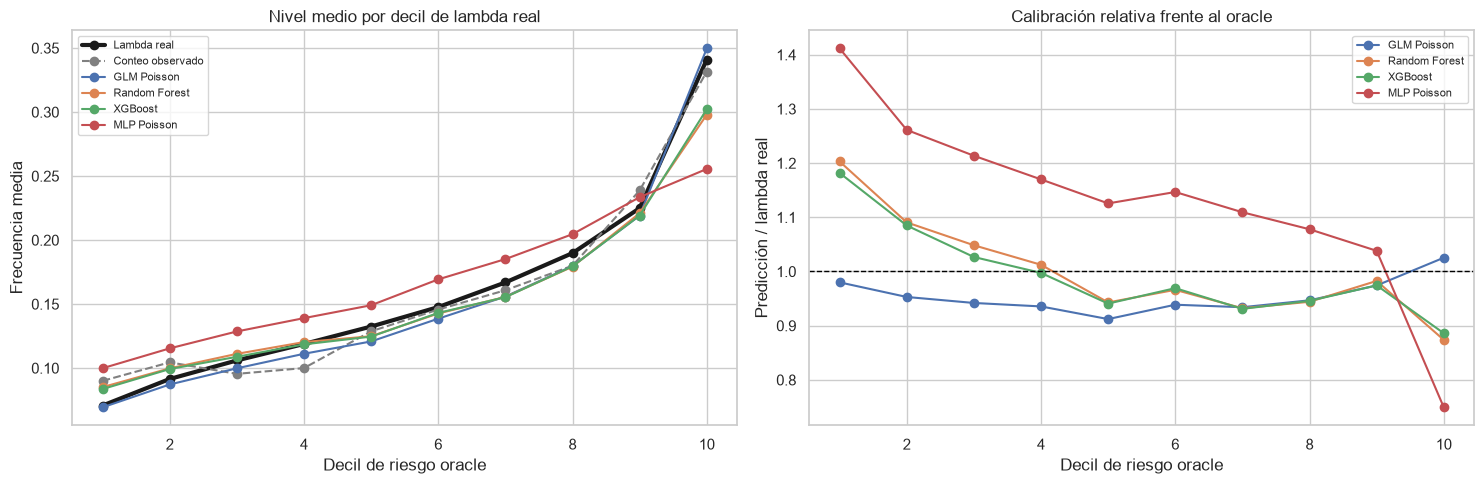

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(quantile_means["decil_riesgo"], quantile_means["lambda_real"], "k-o", lw=3, label="Lambda real")
axes[0].plot(quantile_means["decil_riesgo"], quantile_means["observado"], color="gray", marker="o", ls="--", label="Conteo observado")
for label, column in {
    "GLM Poisson": "GLM_Poisson", "Random Forest": "Random_Forest",
    "XGBoost": "XGBoost", "MLP Poisson": "MLP_Poisson",
}.items():
    axes[0].plot(quantile_means["decil_riesgo"], quantile_means[column], marker="o", label=label)
axes[0].set(title="Nivel medio por decil de lambda real", xlabel="Decil de riesgo oracle", ylabel="Frecuencia media")
axes[0].legend(fontsize=8)

for label, column in {
    "GLM Poisson": "ratio_GLM_Poisson_vs_oracle",
    "Random Forest": "ratio_Random_Forest_vs_oracle",
    "XGBoost": "ratio_XGBoost_vs_oracle",
    "MLP Poisson": "ratio_MLP_Poisson_vs_oracle",
}.items():
    axes[1].plot(quantile_means["decil_riesgo"], quantile_means[column], marker="o", label=label)
axes[1].axhline(1, color="black", ls="--", lw=1)
axes[1].set(title="Calibración relativa frente al oracle", xlabel="Decil de riesgo oracle", ylabel="Predicción / lambda real")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

El patrón por deciles revela una diferencia que la media agregada oculta. En el primer decil, Random Forest y XGBoost sobreestiman el oracle aproximadamente 20% y 18%; el MLP, cerca de 41%. En el décimo decil, los mismos modelos subestiman aproximadamente 13%, 11% y 25%. Esto es **compresión hacia el promedio**: reduce la separación entre riesgos bajos y altos y puede producir subsidios cruzados si las predicciones se trasladan directamente a tarifa.

El GLM permanece cerca del oracle en ambos extremos —aproximadamente −2% en el primer decil y +2.5% en el décimo—. La diferencia entre la línea observada y `lambda_real` no debe atribuirse automáticamente al modelo: representa la realización aleatoria de los conteos dentro de cada decil.

## 12. Predicción frente a `lambda_real`

La diagonal representa recuperación perfecta de la esperanza condicional. Separación vertical indica error de nivel; una nube con pendiente menor que uno sugiere compresión del rango; dispersión alrededor de una relación monotónica afecta Pearson y errores oracle, aunque Spearman puede mantenerse relativamente alto.

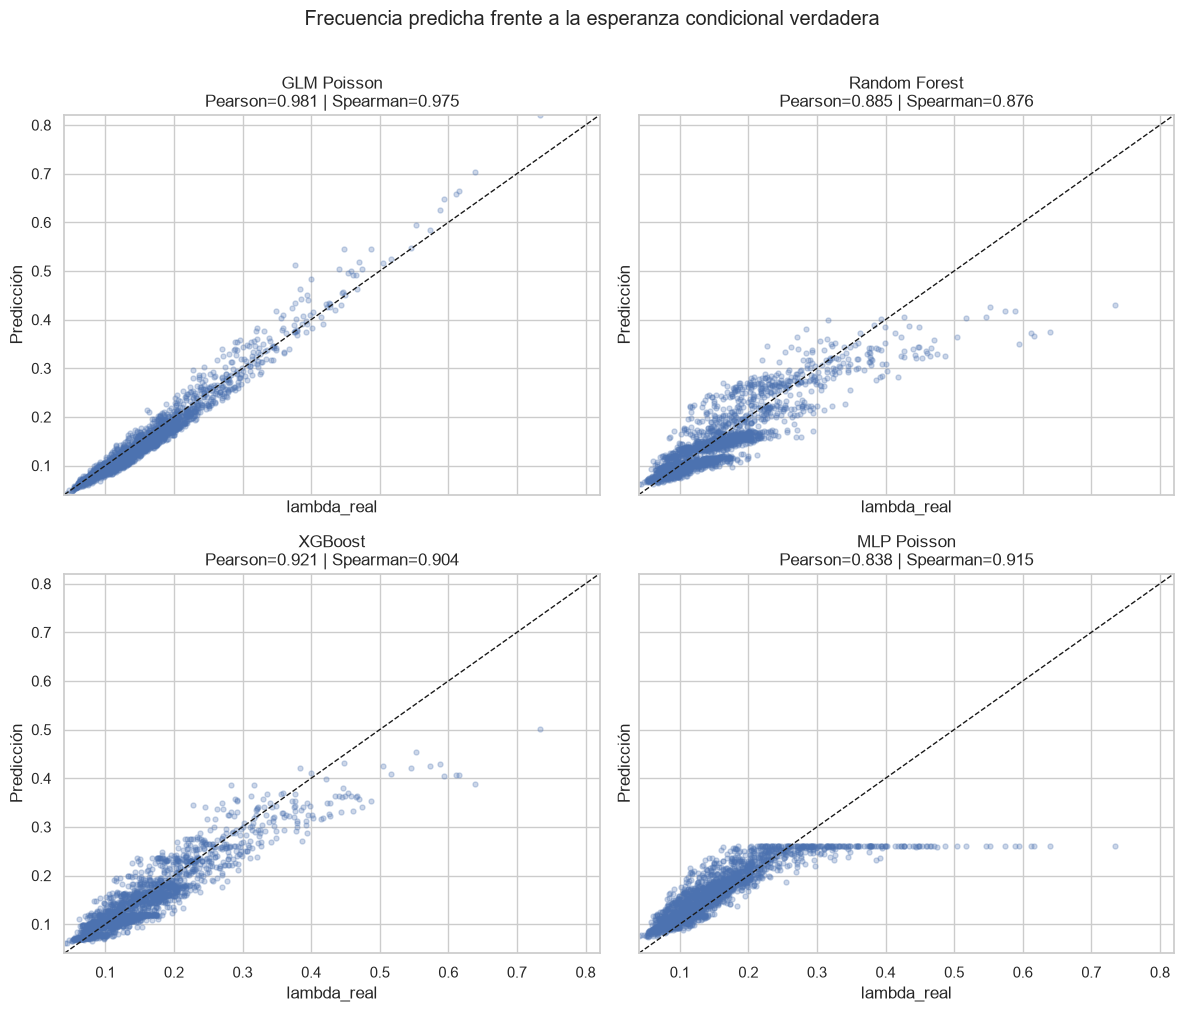

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
lower = min(policy_predictions["lambda_real"].min(), policy_predictions[list(FREQUENCY_MODELS.values())].min().min())
upper = max(policy_predictions["lambda_real"].max(), policy_predictions[list(FREQUENCY_MODELS.values())].max().max())

for ax, (model, column) in zip(axes.ravel(), FREQUENCY_MODELS.items()):
    ax.scatter(policy_predictions["lambda_real"], policy_predictions[column], s=13, alpha=0.28)
    ax.plot([lower, upper], [lower, upper], "k--", lw=1)
    pearson = frequency_diagnostics.loc[frequency_diagnostics.modelo.eq(model), "Pearson_lambda"].iloc[0]
    spearman = frequency_diagnostics.loc[frequency_diagnostics.modelo.eq(model), "Spearman_lambda"].iloc[0]
    ax.set(title=f"{model}\nPearson={pearson:.3f} | Spearman={spearman:.3f}", xlabel="lambda_real", ylabel="Predicción")
    ax.set_xlim(lower, upper); ax.set_ylim(lower, upper)

fig.suptitle("Frecuencia predicha frente a la esperanza condicional verdadera", y=1.01)
plt.tight_layout()
plt.show()

El gráfico hace visible la diferencia entre discriminación y calibración. Random Forest y XGBoost mantienen una relación creciente, pero sus máximos (`≈0.43` y `≈0.50`) quedan por debajo del máximo oracle (`≈0.73`). El MLP comprime aún más el rango (`≈0.074–0.262`): puede ordenar muchas pólizas correctamente —de ahí su Spearman relativamente alto— sin reproducir la magnitud de los extremos. El GLM cubre un rango más próximo al oracle, aunque genera algunas predicciones superiores al máximo oracle de esta muestra.

## 13. Distribución y rango de las predicciones

Los percentiles permiten distinguir cambios de centro, dispersión y extremos. Una distribución más estrecha no es necesariamente más robusta: también puede significar que el modelo suaviza excesivamente la heterogeneidad real.

,serie,mínimo,p01,p05,mediana,media,p95,p99,máximo,desv_est
0,Lambda real,0.040844,0.057960,0.072042,0.139387,0.158894,0.314129,0.448216,0.733814,0.079685
1,GLM Poisson,0.040308,0.056279,0.069737,0.130147,0.153042,0.326085,0.491360,0.820505,0.085314
2,Random Forest,0.061346,0.068949,0.077179,0.134811,0.153696,0.300868,0.364548,0.430154,0.069641
3,XGBoost,0.060755,0.069194,0.075930,0.130707,0.153349,0.300604,0.367928,0.500571,0.069154
4,MLP Poisson,0.073907,0.081954,0.093373,0.162419,0.167968,0.261104,0.261287,0.261748,0.052998


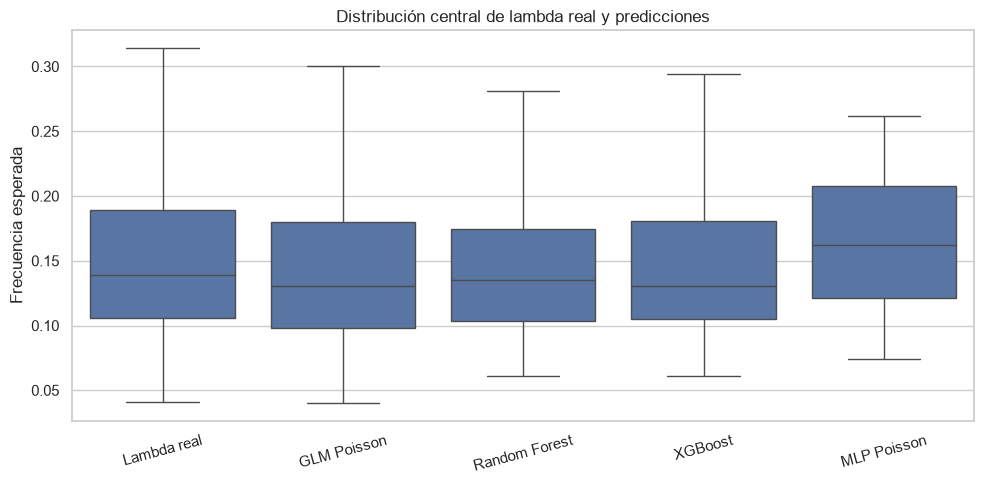

In [20]:
distribution_rows = []
for label, column in {"Lambda real": "lambda_real", **FREQUENCY_MODELS}.items():
    values = policy_predictions[column]
    distribution_rows.append({
        "serie": label, "mínimo": values.min(), "p01": values.quantile(.01),
        "p05": values.quantile(.05), "mediana": values.median(),
        "media": values.mean(), "p95": values.quantile(.95),
        "p99": values.quantile(.99), "máximo": values.max(), "desv_est": values.std(),
    })
frequency_prediction_distribution = pd.DataFrame(distribution_rows)
display(frequency_prediction_distribution.round(6))

long_predictions = policy_predictions[["lambda_real", *FREQUENCY_MODELS.values()]].rename(
    columns={"lambda_real": "Lambda real", **{v: k for k, v in FREQUENCY_MODELS.items()}}
).melt(var_name="serie", value_name="valor")

plt.figure(figsize=(10, 5))
sns.boxplot(data=long_predictions, x="serie", y="valor", showfliers=False)
plt.title("Distribución central de lambda real y predicciones")
plt.xlabel(""); plt.ylabel("Frecuencia esperada")
plt.xticks(rotation=15)
plt.tight_layout(); plt.show()

## 14. Distribución de errores oracle

Se define \(e_i=\hat\lambda_i-\lambda_i\). Un error centrado cerca de cero indica ausencia de sesgo local en la mayor parte de la cartera; colas asimétricas muestran dónde el modelo falla con mayor intensidad. En particular, una cola negativa larga es consistente con subestimación de riesgos altos.

,media,mediana,desviación,mínimo,máximo
modelo,,,,,
GLM Poisson,-0.005852,-0.007024,0.016884,-0.037360,0.136095
MLP Poisson,0.009074,0.015319,0.045616,-0.472709,0.099807
Random Forest,-0.005199,-0.004112,0.037181,-0.303660,0.117901
XGBoost,-0.005545,-0.003939,0.031292,-0.251339,0.117077


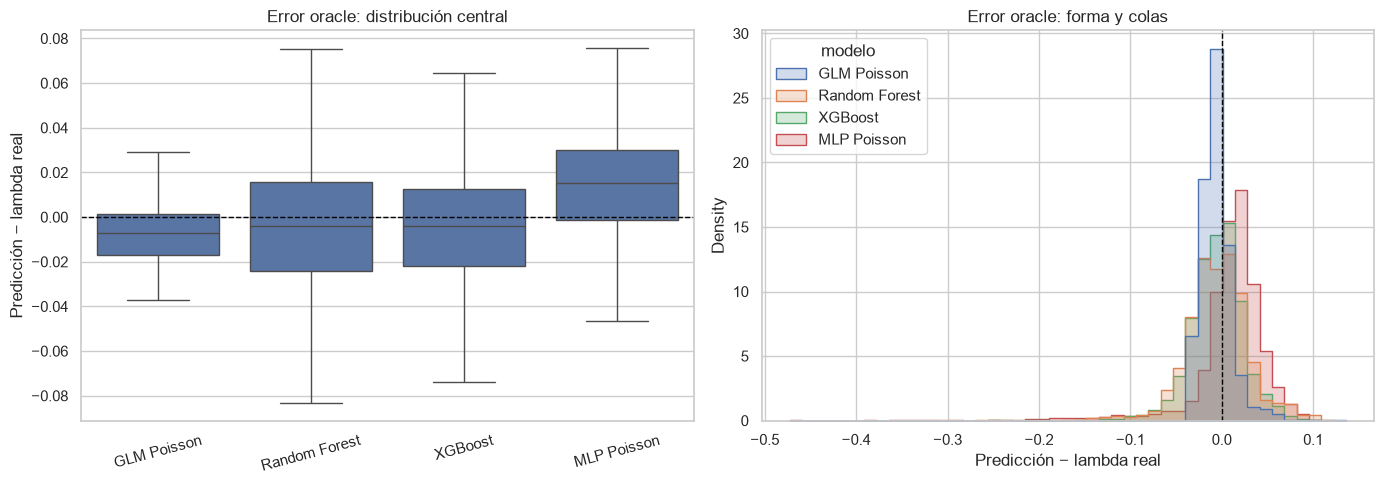

In [21]:
oracle_errors = pd.concat([
    pd.DataFrame({
        "modelo": model,
        "error_oracle": policy_predictions[column] - policy_predictions["lambda_real"],
    })
    for model, column in FREQUENCY_MODELS.items()
], ignore_index=True)

error_summary = oracle_errors.groupby("modelo")["error_oracle"].agg(
    media="mean", mediana="median", desviación="std",
    mínimo="min", máximo="max",
)
display(error_summary.round(6))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=oracle_errors, x="modelo", y="error_oracle", showfliers=False, ax=axes[0])
axes[0].axhline(0, color="black", ls="--", lw=1)
axes[0].set(title="Error oracle: distribución central", xlabel="", ylabel="Predicción − lambda real")
axes[0].tick_params(axis="x", rotation=15)

sns.histplot(data=oracle_errors, x="error_oracle", hue="modelo", element="step", stat="density", common_norm=False, bins=45, ax=axes[1])
axes[1].axvline(0, color="black", ls="--", lw=1)
axes[1].set(title="Error oracle: forma y colas", xlabel="Predicción − lambda real")

plt.tight_layout(); plt.show()

Las colas negativas de los modelos flexibles confirman que sus mayores errores aparecen al subestimar pólizas de riesgo alto. El MLP tiene una mediana positiva, coherente con la sobreestimación agregada, pero simultáneamente una cola negativa mucho más larga: sobreestima buena parte de los riesgos bajos y subestima los extremos altos. La media agregada por sí sola no mostraría esta combinación.

## 15. Perfiles marginales por variables de riesgo

Las predicciones DL conservan las seis features originales de test, lo que permite contrastar perfiles descriptivos. Para variables numéricas se agrupa por cuantiles; para categóricas se calcula la media por categoría.

Estos gráficos **no son efectos causales ni partial dependence**: cada punto promedia la distribución observada de las demás variables dentro del grupo. Su función es detectar si un modelo aplana, exagera o desplaza patrones visibles en `lambda_real`.

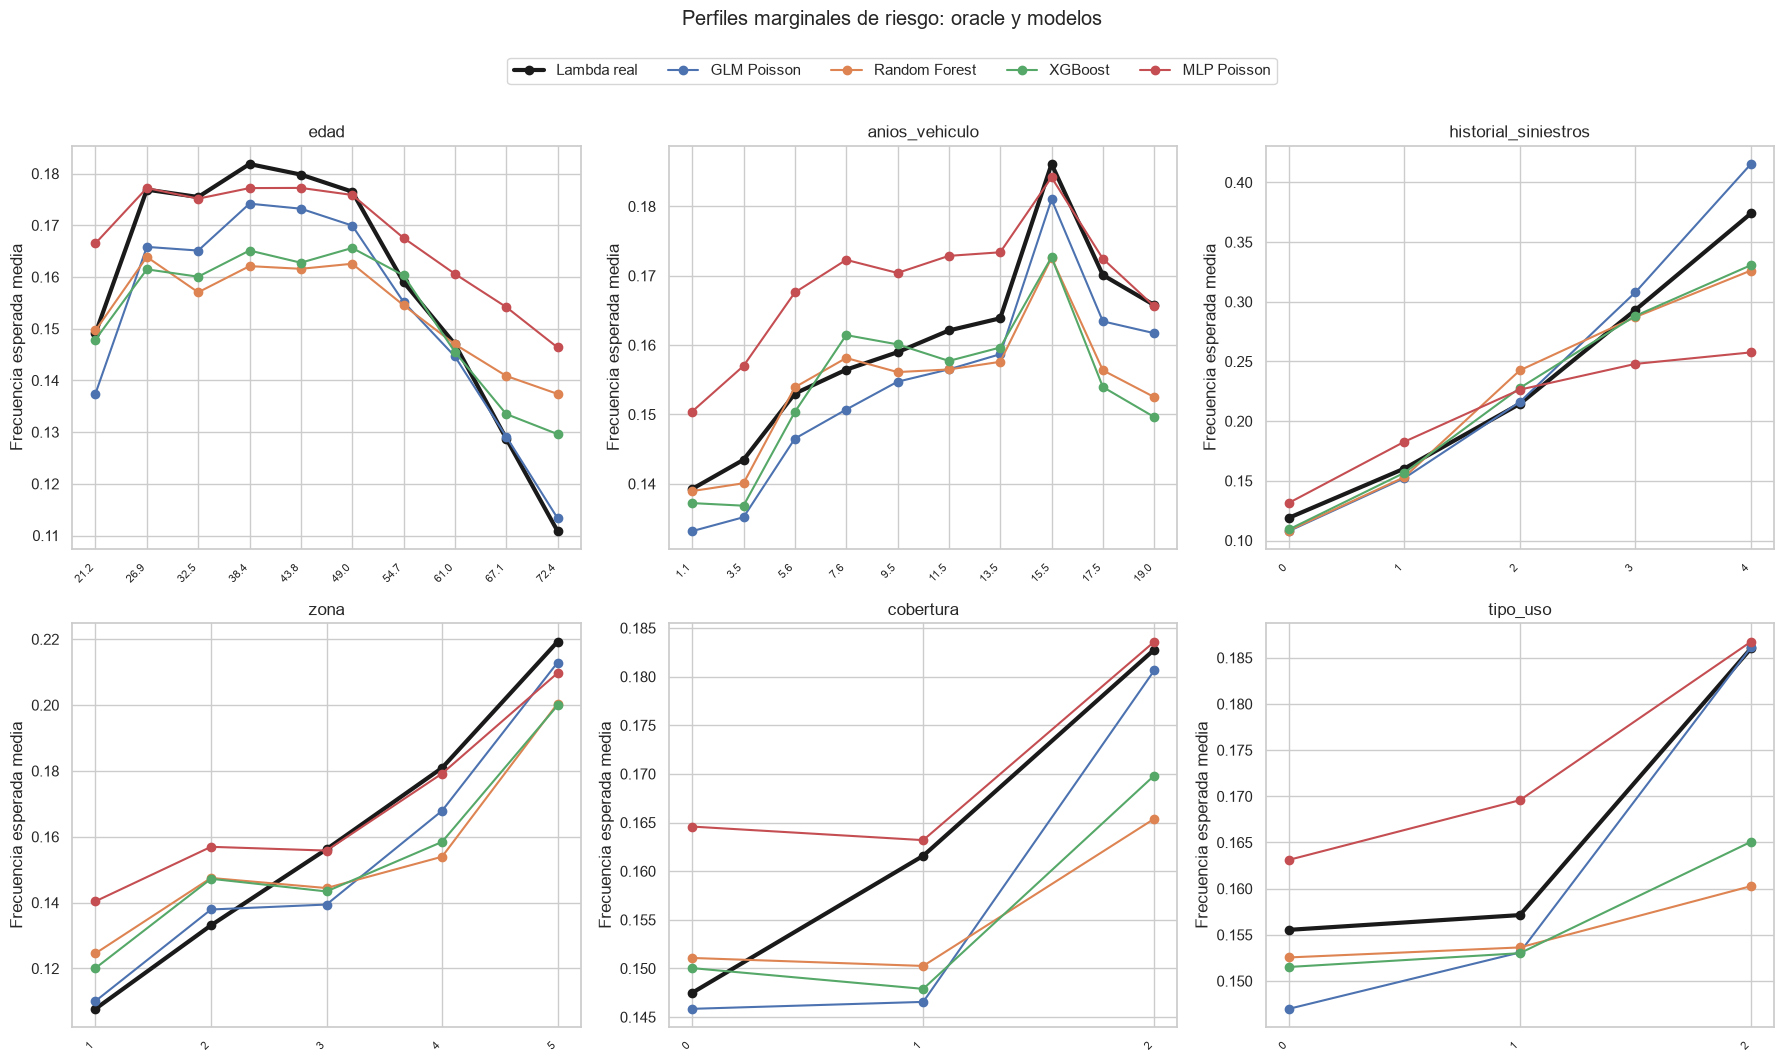

In [22]:
FEATURES = ["edad", "anios_vehiculo", "historial_siniestros", "zona", "cobertura", "tipo_uso"]
missing_features = [f for f in FEATURES if f not in policy_predictions.columns]
assert not missing_features, f"No están disponibles las features: {missing_features}"

def feature_profile(frame, feature):
    columns = [feature, "lambda_real", *FREQUENCY_MODELS.values()]
    data = frame[columns].dropna().copy()
    if pd.api.types.is_numeric_dtype(data[feature]) and data[feature].nunique() > 10:
        data["grupo"] = pd.qcut(data[feature], q=10, duplicates="drop")
        profile = data.groupby("grupo", observed=True).mean(numeric_only=True)
        profile["etiqueta"] = profile[feature].round(1).astype(str)
    else:
        profile = data.groupby(feature, observed=True).mean(numeric_only=True)
        profile = profile.sort_values("lambda_real")
        profile["etiqueta"] = profile.index.astype(str)
    return profile.reset_index(drop=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, feature in zip(axes.ravel(), FEATURES):
    profile = feature_profile(policy_predictions, feature)
    x = np.arange(len(profile))
    ax.plot(x, profile["lambda_real"], "k-o", lw=3, label="Lambda real")
    for model, column in FREQUENCY_MODELS.items():
        ax.plot(x, profile[column], marker="o", label=model)
    ax.set_title(feature)
    ax.set_xticks(x)
    ax.set_xticklabels(profile["etiqueta"], rotation=45, ha="right", fontsize=8)
    ax.set_ylabel("Frecuencia esperada media")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=5, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("Perfiles marginales de riesgo: oracle y modelos", y=1.06)
plt.tight_layout(); plt.show()

### Síntesis de frecuencia, sin ganador global

- **Conteo observado:** los cuatro modelos tienen RMSE y Poisson deviance muy próximos. La aleatoriedad del conteo limita cuánto se separan en estas métricas individuales.
- **Esperanza condicional:** las diferencias oracle son bastante mayores. El GLM reproduce con especial precisión el DGP correctamente especificado; XGBoost es el modelo flexible más próximo en escala lineal, mientras Random Forest y MLP muestran mayor error de nivel.
- **Ordenamiento:** todos conservan señal. Pearson y Spearman no son intercambiables: el MLP ordena mejor de lo que calibra linealmente, evidenciado por `Spearman > Pearson`.
- **Calibración:** GLM, Random Forest y XGBoost subestiman ligeramente el promedio; el MLP lo sobreestima. Por deciles, los modelos flexibles comprimen el rango, elevando riesgos bajos y reduciendo riesgos altos.
- **Implicación práctica:** dos modelos con error observado casi idéntico pueden producir segmentaciones tarifarias distintas. En un DGP donde la forma paramétrica está bien especificada, la complejidad adicional no garantiza recuperar mejor la heterogeneidad real; puede aportar flexibilidad, pero también suavizar extremos y dificultar la calibración.

Esta síntesis se limita a frecuencia. No se combina con severidad o prima pura y no se utiliza para retunear ninguno de los modelos congelados.